In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

In [ ]:
def plot_decision_boundary(X, y, models, model_names, ax, title):
    # Create a mesh to plot in
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Plot the background decision regions
    colors = ['g', 'b', 'm']

    # Plot the original data points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral, edgecolors='k', s=30, zorder=3)

    # Plot the decision boundaries
    for i, model in enumerate(models):
        # Predict on the meshgrid
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot the contour lines
        contour = ax.contour(xx, yy, Z, levels=[0.5], colors=colors[i], linestyles=['-'], linewidths=[2])

        # Add labels for the contours for better identification
        fmt = {level: model_names[i] for level in contour.levels}
        ax.clabel(contour, contour.levels, inline=True, fmt=fmt, fontsize=12)

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)
    ax.grid(False)

def run_experiment(dataset_name, X, y):
    print(f"==== Running Experiment for {dataset_name} ====")

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

    # Initialize models
    log_reg = LogisticRegression(solver='lbfgs')
    svm_linear = SVC(kernel='linear', probability=True) # probability=True for decision boundary
    svm_rbf = SVC(kernel='rbf', gamma='auto', probability=True) # gamma='auto' is a default

    models = [log_reg, svm_linear, svm_rbf]
    model_names = ['Logistic Regression', 'Linear SVM', 'RBF SVM']

    accuracies = {}

    # Train and evaluate each model
    for model, name in zip(models, model_names):
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        accuracies[name] = accuracy
        print(f"Test Accuracy for {name}: {accuracy:.4f}")

    # Plotting the results
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    plot_decision_boundary(X_test, y_test, models, model_names, ax, f'Decision Boundaries on {dataset_name}')
    plt.show()

    return accuracies

Performing the Experiments

==== Running Experiment for Moons Dataset ====
Training Logistic Regression...
Test Accuracy for Logistic Regression: 0.8360
Training Linear SVM...
Test Accuracy for Linear SVM: 0.8360
Training RBF SVM...
Test Accuracy for RBF SVM: 0.9160


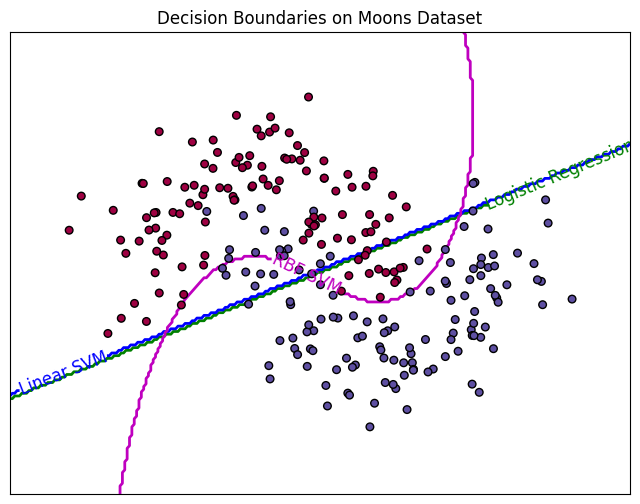

==== Running Experiment for Linear Dataset ====
Training Logistic Regression...
Test Accuracy for Logistic Regression: 0.8600
Training Linear SVM...
Test Accuracy for Linear SVM: 0.9000
Training RBF SVM...
Test Accuracy for RBF SVM: 0.9360


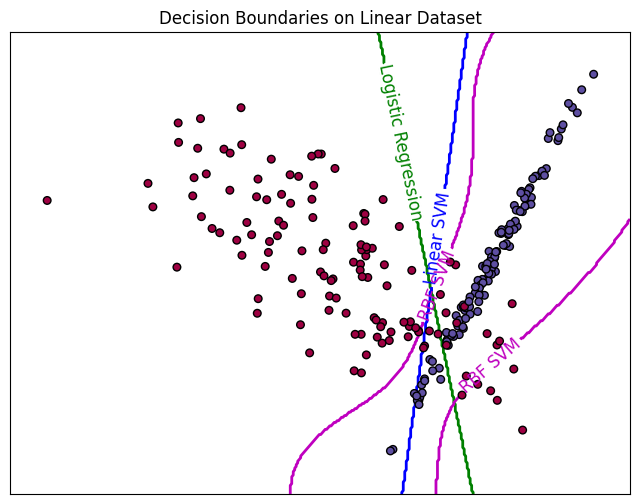

In [ ]:
# Dataset 1: Non-Linearly Separable Data (Moons)
X_moons, y_moons = make_moons(n_samples=500, noise=0.25, random_state=42)

# Dataset 2: Linearly Separable Data
X_linear, y_linear = make_classification(n_samples=500, n_features=2, n_redundant=0,
                                         n_informative=2, n_clusters_per_class=1, flip_y=0,
                                         random_state=42)

# Run experiments for both datasets
moons_accuracies = run_experiment("Moons Dataset", X_moons, y_moons)
linear_accuracies = run_experiment("Linear Dataset", X_linear, y_linear)



In [ ]:
# Create and print the final summary table using pandas
summary_data = {
    'Moons Dataset Accuracy (%)': {name: f"{acc*100:.2f}" for name, acc in moons_accuracies.items()},
    'Linear Dataset Accuracy (%)': {name: f"{acc*100:.2f}" for name, acc in linear_accuracies.items()}
}
summary_df = pd.DataFrame(summary_data)

print("\n==== Final Summary Table ====")
print(summary_df)



==== Final Summary Table ====
                    Moons Dataset Accuracy (%) Linear Dataset Accuracy (%)
Logistic Regression                      83.60                       86.00
Linear SVM                               83.60                       90.00
RBF SVM                                  91.60                       93.60
